In [1]:
import pyspark
import numpy as np 
import pandas as pd 
import math
import random 
import os
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

### Data Staging

In [2]:
#file paths
country_wise_latest = "C:\\Users\\pmoh3005\\OneDrive - 7-Eleven, Inc\\Desktop\\development\\7-11apps\\Covid_EDA\\input\\country_wise_latest.csv"
covid_19 = "C:\\Users\\pmoh3005\\OneDrive - 7-Eleven, Inc\\Desktop\\development\\7-11apps\\Covid_EDA\\input\\covid_19_clean_complete.csv"
day_wise = "C:\\Users\\pmoh3005\\OneDrive - 7-Eleven, Inc\\Desktop\\development\\7-11apps\\Covid_EDA\\input\\day_wise.csv"
full_grouped = "C:\\Users\\pmoh3005\\OneDrive - 7-Eleven, Inc\\Desktop\\development\\7-11apps\\Covid_EDA\\input\\full_grouped.csv"
usa_county = "C:\\Users\\pmoh3005\\OneDrive - 7-Eleven, Inc\\Desktop\\development\\7-11apps\\Covid_EDA\\input\\usa_county_wise.csv"
world = "C:\\Users\\pmoh3005\\OneDrive - 7-Eleven, Inc\\Desktop\\development\\7-11apps\\Covid_EDA\\input\\worldometer_data.csv"

In [3]:
spark = SparkSession.builder.appName("covid").getOrCreate()

In [33]:
country = spark.read.csv(country_wise_latest,header=True,inferSchema=True)
covid = spark.read.csv(covid_19,header=True,inferSchema=True)
days = spark.read.csv(day_wise,header=True,inferSchema=True)
full = spark.read.csv(full_grouped,header=True,inferSchema=True)
usa = spark.read.csv(usa_county,header=True,inferSchema=True)
wrld = spark.read.csv(world,header=True,inferSchema=True)

In [34]:
print(f"All Schema's\nCountry = {country.schema}")
print(f"Covid = {covid.schema}")
print(f"Day wise data = {days.schema}")
print(f"Full grouped data = {full.schema}")
print(f"USA Covid data = {usa.schema}")
print(f"World data = {wrld.schema}")

All Schema's
Country = StructType([StructField('Country/Region', StringType(), True), StructField('Confirmed', IntegerType(), True), StructField('Deaths', IntegerType(), True), StructField('Recovered', IntegerType(), True), StructField('Active', IntegerType(), True), StructField('New cases', IntegerType(), True), StructField('New deaths', IntegerType(), True), StructField('New recovered', IntegerType(), True), StructField('Deaths / 100 Cases', DoubleType(), True), StructField('Recovered / 100 Cases', DoubleType(), True), StructField('Deaths / 100 Recovered', StringType(), True), StructField('Confirmed last week', IntegerType(), True), StructField('1 week change', IntegerType(), True), StructField('1 week % increase', DoubleType(), True), StructField('WHO Region', StringType(), True)])
Covid = StructType([StructField('Province/State', StringType(), True), StructField('Country/Region', StringType(), True), StructField('Lat', DoubleType(), True), StructField('Long', DoubleType(), True), S

In [35]:
print("Columns")
print(f"Country = {country.columns}")
print(f"Covid = {covid.columns}")
print(f"Day wise data = {days.columns}")
print(f"Full grouped data = {full.columns}")
print(f"USA Covid data = {usa.columns}")
print(f"World data = {wrld.columns}")


Columns
Country = ['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'Confirmed last week', '1 week change', '1 week % increase', 'WHO Region']
Covid = ['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']
Day wise data = ['Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'No. of countries']
Full grouped data = ['Date', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'WHO Region']
USA Covid data = ['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Lat', 'Long_', 'Combined_Key', 'Date', 'Confirmed', 'Deaths']
World data = ['Country/Region', 'Continent', 'Population', 'TotalCases'

In [36]:
print("Count number of rows")
print(f"Country = {country.count()}")
print(f"Covid = {covid.count()}")
print(f"Day wise data = {days.count()}")
print(f"Full grouped data = {full.count()}")
print(f"USA Covid data = {usa.count()}")
print(f"World data = {wrld.count()}")


Count number of rows
Country = 187
Covid = 49068
Day wise data = 188
Full grouped data = 35156
USA Covid data = 627920
World data = 209


In [37]:
# NA or 0 values in the table for each column go table wise
# Country table
# in psark create views then do sql ops on it 
print("="*60+"Country"+"="*60)
country.show(5)

============================================================Country============================================================
+--------------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+----------------------+-------------------+-------------+-----------------+--------------------+
|Country/Region|Confirmed|Deaths|Recovered|Active|New cases|New deaths|New recovered|Deaths / 100 Cases|Recovered / 100 Cases|Deaths / 100 Recovered|Confirmed last week|1 week change|1 week % increase|          WHO Region|
+--------------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+----------------------+-------------------+-------------+-----------------+--------------------+
|   Afghanistan|    36263|  1269|    25198|  9796|      106|        10|           18|               3.5|                69.49|                  5.04|              35526|          737|             2.07|Ea

In [38]:
print("Covid data")
covid.show(5)

Covid data
+--------------+--------------+--------+---------+----------+---------+------+---------+------+--------------------+
|Province/State|Country/Region|     Lat|     Long|      Date|Confirmed|Deaths|Recovered|Active|          WHO Region|
+--------------+--------------+--------+---------+----------+---------+------+---------+------+--------------------+
|          NULL|   Afghanistan|33.93911|67.709953|2020-01-22|        0|     0|        0|     0|Eastern Mediterra...|
|          NULL|       Albania| 41.1533|  20.1683|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|       Algeria| 28.0339|   1.6596|2020-01-22|        0|     0|        0|     0|              Africa|
|          NULL|       Andorra| 42.5063|   1.5218|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|        Angola|-11.2027|  17.8739|2020-01-22|        0|     0|        0|     0|              Africa|
+--------------+--------------+--------+---------+---

In [39]:
print("Day wise")
days.show(5)

Day wise
+----------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+----------------------+----------------+
|      Date|Confirmed|Deaths|Recovered|Active|New cases|New deaths|New recovered|Deaths / 100 Cases|Recovered / 100 Cases|Deaths / 100 Recovered|No. of countries|
+----------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+----------------------+----------------+
|2020-01-22|      555|    17|       28|   510|        0|         0|            0|              3.06|                 5.05|                 60.71|               6|
|2020-01-23|      654|    18|       30|   606|       99|         1|            2|              2.75|                 4.59|                  60.0|               8|
|2020-01-24|      941|    26|       36|   879|      287|         8|            6|              2.76|                 3.83|                 72.22|               9|
|2020-01-25| 

In [40]:
print("full ? ")
full.show(5)

full ? 
+----------+--------------+---------+------+---------+------+---------+----------+-------------+--------------------+
|      Date|Country/Region|Confirmed|Deaths|Recovered|Active|New cases|New deaths|New recovered|          WHO Region|
+----------+--------------+---------+------+---------+------+---------+----------+-------------+--------------------+
|2020-01-22|   Afghanistan|        0|     0|        0|     0|        0|         0|            0|Eastern Mediterra...|
|2020-01-22|       Albania|        0|     0|        0|     0|        0|         0|            0|              Europe|
|2020-01-22|       Algeria|        0|     0|        0|     0|        0|         0|            0|              Africa|
|2020-01-22|       Andorra|        0|     0|        0|     0|        0|         0|            0|              Europe|
|2020-01-22|        Angola|        0|     0|        0|     0|        0|         0|            0|              Africa|
+----------+--------------+---------+------+----

In [41]:
print("USA data")
usa.show(5)

USA data
+--------+----+----+-----+-------+--------+--------------------+--------------+-------------------+------------------+--------------------+-------+---------+------+
|     UID|iso2|iso3|code3|   FIPS|  Admin2|      Province_State|Country_Region|                Lat|             Long_|        Combined_Key|   Date|Confirmed|Deaths|
+--------+----+----+-----+-------+--------+--------------------+--------------+-------------------+------------------+--------------------+-------+---------+------+
|      16|  AS| ASM|   16|   60.0|    NULL|      American Samoa|            US|-14.270999999999999|          -170.132|  American Samoa, US|1/22/20|        0|     0|
|     316|  GU| GUM|  316|   66.0|    NULL|                Guam|            US|            13.4443|          144.7937|            Guam, US|1/22/20|        0|     0|
|     580|  MP| MNP|  580|   69.0|    NULL|Northern Mariana ...|            US|            15.0979|          145.6739|Northern Mariana ...|1/22/20|        0|     0|
|

In [42]:
print("World data")
wrld.show(5)

World data
+--------------+-------------+----------+----------+--------+-----------+---------+--------------+------------+-----------+----------------+----------------+-------------+----------+------------+--------------+
|Country/Region|    Continent|Population|TotalCases|NewCases|TotalDeaths|NewDeaths|TotalRecovered|NewRecovered|ActiveCases|Serious,Critical|Tot Cases/1M pop|Deaths/1M pop|TotalTests|Tests/1M pop|    WHO Region|
+--------------+-------------+----------+----------+--------+-----------+---------+--------------+------------+-----------+----------------+----------------+-------------+----------+------------+--------------+
|           USA|North America| 331198130|   5032179|    NULL|     162804|     NULL|       2576668|        NULL|    2292707|           18296|           15194|        492.0|  63139605|      190640|      Americas|
|        Brazil|South America| 212710692|   2917562|    NULL|      98644|     NULL|       2047660|        NULL|     771258|            8318|     

### Data Cleaning

In [43]:
# # sql statements for nulls or 0s and unique checks 
# country.createOrReplaceTempView("tableCountry")
# print("NULL or NA checks")
# # rename the column for country 
# spark.sql("") 
# spark.sql("SELECT count(*) from tableCountry where Country/Region is NULL").show()
# use in built methods in spark 
country = country.withColumnRenamed("Country/Region","Area") \
                .withColumnRenamed("Deaths / 100 Cases","Dper100") \
                .withColumnRenamed("Recovered / 100 Cases","Rper100") \
                .withColumnRenamed("Deaths / 100 Recovered","DRper100")
covid = covid.withColumnRenamed("Country/Region","Area") \
            .withColumnRenamed("Province/State","Sector")
days = days.withColumnRenamed("Deaths / 100 Cases","Dper100") \
            .withColumnRenamed("Recovered / 100 Cases","Rper100") \
            .withColumnRenamed("Deaths / 100 Recovered","DRper100")
full = full.withColumnRenamed("Country/Region","Area")
usa = usa.withColumnRenamed("Province_State","Sector")\
        .withColumnRenamed("Country_Region","Area") # may have errs as US here check in country identity
wrld = wrld.withColumnRenamed("Country/Region","Area")\
            .withColumnRenamed("Tot Cases/1M pop","totPer1M")\
            .withColumnRenamed("Deaths/1M pop","deathsPer1M")

In [44]:
def task2_fill_sector(df):
    """Replace null Sector (Province/State) with 'Unknown'."""
    null_report = (
        df.groupBy("Area")
          .agg(F.sum(F.col("Sector").isNull().cast("int")).alias("null_sector_count"))
          .filter(F.col("null_sector_count") > 0)
          .orderBy(F.col("null_sector_count").desc())
    )
    print("\n[Task 2] Country-wise NULL Sector count:")
    null_report.show(20, truncate=False)

    df_clean = df.fillna({"Sector": "Unknown"})
    return df_clean
covid = task2_fill_sector(covid)
covid.show()


[Task 2] Country-wise NULL Sector count:
+--------------+-----------------+
|Area          |null_sector_count|
+--------------+-----------------+
|Chad          |188              |
|Paraguay      |188              |
|Russia        |188              |
|Yemen         |188              |
|Senegal       |188              |
|Cabo Verde    |188              |
|Sweden        |188              |
|Guyana        |188              |
|Eritrea       |188              |
|Philippines   |188              |
|Burma         |188              |
|Djibouti      |188              |
|Malaysia      |188              |
|Singapore     |188              |
|Fiji          |188              |
|Turkey        |188              |
|Malawi        |188              |
|Western Sahara|188              |
|Iraq          |188              |
|Germany       |188              |
+--------------+-----------------+
only showing top 20 rows
+--------------------+-------------------+---------+----------+----------+---------+------+--

In [45]:
# std country names map replace values
def task3_standardize_countries(*dfs):
    """
    Apply a lookup table to unify country name variants across all DataFrames.
    Extend the mapping dict as needed.
    """
    mapping = {
        "US"             : "USA",
        "Korea, South"   : "South Korea",
        "Taiwan*"        : "Taiwan",
        "Czechia"        : "Czech Republic",
        "Congo (Kinshasa)": "DR Congo",
        "Congo (Brazzaville)": "Congo",
        "Burma"          : "Myanmar",
    }

    def standardize(df):
        expr = F.col("Area")
        for old, new in mapping.items():
            expr = F.when(F.col("Area") == old, new).otherwise(expr)
        return df.withColumn("Area", expr)

    return [standardize(df) for df in dfs]

country, covid, full, usa, wrld = task3_standardize_countries(
    country, covid, full, usa, wrld
)

In [46]:
def task4_remove_duplicates(df, subset=("Area", "Date")):
    before = df.count()
    df_dedup = df.dropDuplicates(list(subset))
    after = df_dedup.count()
    print(f"\n[Task 4] Duplicates removed: {before - after:,}  |  Remaining rows: {after:,}")
    return df_dedup

full = task4_remove_duplicates(full)



[Task 4] Duplicates removed: 0  |  Remaining rows: 35,156


### Aggregations

In [47]:
def task5_top10_confirmed(df):
    print("\n[Task 5] Top 10 Countries — Confirmed Cases")
    result = (
        df.select("Area", "Confirmed")
          .orderBy(F.col("Confirmed").desc())
          .limit(10)
    )
    result.show(truncate=False)
    return result

top10_confirmed = task5_top10_confirmed(country)


[Task 5] Top 10 Countries — Confirmed Cases
+--------------+---------+
|Area          |Confirmed|
+--------------+---------+
|USA           |4290259  |
|Brazil        |2442375  |
|India         |1480073  |
|Russia        |816680   |
|South Africa  |452529   |
|Mexico        |395489   |
|Peru          |389717   |
|Chile         |347923   |
|United Kingdom|301708   |
|Iran          |293606   |
+--------------+---------+



In [48]:
def task6_top10_death_rate(df):
    print("\n[Task 6] Top 10 Countries — Death Rate (Deaths per 100 Cases)")
    result = (
        df.select("Area", "Dper100")
          .orderBy(F.col("Dper100").desc())
          .limit(10)
    )
    result.show(truncate=False)
    return result

top10_death_rate = task6_top10_death_rate(country)


[Task 6] Top 10 Countries — Death Rate (Deaths per 100 Cases)
+--------------+-------+
|Area          |Dper100|
+--------------+-------+
|Yemen         |28.56  |
|United Kingdom|15.19  |
|Belgium       |14.79  |
|Italy         |14.26  |
|France        |13.71  |
|Hungary       |13.4   |
|Netherlands   |11.53  |
|Mexico        |11.13  |
|Spain         |10.44  |
|Western Sahara|10.0   |
+--------------+-------+



In [49]:
def task7_who_region_totals(df):
    print("\n[Task 7] WHO Region — Confirmed / Deaths / Recovered")
    result = (
        df.groupBy("WHO Region")
          .agg(
              F.sum("Confirmed") .alias("Total_Confirmed"),
              F.sum("Deaths")    .alias("Total_Deaths"),
              F.sum("Recovered") .alias("Total_Recovered"),
          )
          .orderBy(F.col("Total_Confirmed").desc())
    )
    result.show(truncate=False)
    return result

who_region_totals = task7_who_region_totals(country)



[Task 7] WHO Region — Confirmed / Deaths / Recovered
+---------------------+---------------+------------+---------------+
|WHO Region           |Total_Confirmed|Total_Deaths|Total_Recovered|
+---------------------+---------------+------------+---------------+
|Americas             |8839286        |342732      |4468616        |
|Europe               |3299523        |211144      |1993723        |
|South-East Asia      |1835297        |41349       |1156933        |
|Eastern Mediterranean|1490744        |38339       |1201400        |
|Africa               |723207         |12223       |440645         |
|Western Pacific      |292428         |8249        |206770         |
+---------------------+---------------+------------+---------------+



### Time-Series 

In [50]:
def task8_daily_new_cases(df):
    print("\n[Task 8] Daily Global New Cases")
    result = (
        df.select("Date", "New cases")
          .orderBy("Date")
    )
    result.show(20, truncate=False)
    return result

daily_new_cases = task8_daily_new_cases(days)


[Task 8] Daily Global New Cases
+----------+---------+
|Date      |New cases|
+----------+---------+
|2020-01-22|0        |
|2020-01-23|99       |
|2020-01-24|287      |
|2020-01-25|493      |
|2020-01-26|684      |
|2020-01-27|809      |
|2020-01-28|2651     |
|2020-01-29|588      |
|2020-01-30|2068     |
|2020-01-31|1693     |
|2020-02-01|2111     |
|2020-02-02|4749     |
|2020-02-03|3100     |
|2020-02-04|4011     |
|2020-02-05|3745     |
|2020-02-06|3159     |
|2020-02-07|3532     |
|2020-02-08|2734     |
|2020-02-09|3027     |
|2020-02-10|2538     |
+----------+---------+
only showing top 20 rows


In [51]:
def task9_death_growth(df):
    print("\n[Task 9] Daily Death Growth %")
    w = Window.orderBy("Date")
    result = (
        df.select("Date", "New deaths")
          .withColumn("prev_deaths", F.lag("New deaths", 1).over(w))
          .withColumn(
              "death_growth_pct",
              F.when(
                  F.col("prev_deaths").isNotNull() & (F.col("prev_deaths") > 0),
                  (F.col("New deaths") / F.col("prev_deaths") * 100).cast(DoubleType())
              ).otherwise(F.lit(None))
          )
          .orderBy("Date")
    )
    result.show(20, truncate=False)
    return result

death_growth = task9_death_growth(days)


[Task 9] Daily Death Growth %
+----------+----------+-----------+------------------+
|Date      |New deaths|prev_deaths|death_growth_pct  |
+----------+----------+-----------+------------------+
|2020-01-22|0         |NULL       |NULL              |
|2020-01-23|1         |0          |NULL              |
|2020-01-24|8         |1          |800.0             |
|2020-01-25|16        |8          |200.0             |
|2020-01-26|14        |16         |87.5              |
|2020-01-27|26        |14         |185.71428571428572|
|2020-01-28|49        |26         |188.46153846153845|
|2020-01-29|2         |49         |4.081632653061225 |
|2020-01-30|38        |2          |1900.0            |
|2020-01-31|42        |38         |110.5263157894737 |
|2020-02-01|46        |42         |109.52380952380953|
|2020-02-02|103       |46         |223.91304347826087|
|2020-02-03|64        |103        |62.13592233009708 |
|2020-02-04|66        |64         |103.125           |
|2020-02-05|72        |66         

In [52]:
def task10_monthly_growth(df):
    print("\n[Task 10] Monthly COVID Case Growth")
    result = (
        df.withColumn("Month", F.month("Date"))
          .withColumn("Year",  F.year("Date"))
          .groupBy("Year", "Month")
          .agg(F.sum("Confirmed").alias("Monthly_Confirmed"))
          .orderBy("Year", "Month")
    )
    result.show(truncate=False)
    return result

monthly_growth = task10_monthly_growth(full)


[Task 10] Monthly COVID Case Growth
+----+-----+-----------------+
|Year|Month|Monthly_Confirmed|
+----+-----+-----------------+
|2020|1    |38534            |
|2020|2    |1663437          |
|2020|3    |9002815          |
|2020|4    |63391662         |
|2020|5    |144990399        |
|2020|6    |246525787        |
|2020|7    |362895848        |
+----+-----+-----------------+



### Window functions 

In [53]:
def task11_top5_per_region(df):
    print("\n[Task 11] Top 5 Countries per WHO Region")
    w = Window.partitionBy("WHO Region").orderBy(F.col("Confirmed").desc())
    result = (
        df.withColumn("region_rank", F.dense_rank().over(w))
          .filter(F.col("region_rank") <= 5)
          .select("WHO Region", "Area", "Confirmed", "region_rank")
          .orderBy("WHO Region", "region_rank")
    )
    result.show(50, truncate=False)
    return result

top5_per_region = task11_top5_per_region(country)


[Task 11] Top 5 Countries per WHO Region
+---------------------+--------------+---------+-----------+
|WHO Region           |Area          |Confirmed|region_rank|
+---------------------+--------------+---------+-----------+
|Africa               |South Africa  |452529   |1          |
|Africa               |Nigeria       |41180    |2          |
|Africa               |Ghana         |33624    |3          |
|Africa               |Algeria       |27973    |4          |
|Africa               |Kenya         |17975    |5          |
|Americas             |USA           |4290259  |1          |
|Americas             |Brazil        |2442375  |2          |
|Americas             |Mexico        |395489   |3          |
|Americas             |Peru          |389717   |4          |
|Americas             |Chile         |347923   |5          |
|Eastern Mediterranean|Iran          |293606   |1          |
|Eastern Mediterranean|Pakistan      |274289   |2          |
|Eastern Mediterranean|Saudi Arabia  |26893

In [58]:
def task12_daily_increase(df):
    print("\n[Task 12] Country-wise Daily Case Increase")
    w = Window.partitionBy("Area").orderBy("Date")
    result = (
        df.withColumn("prev_confirmed", F.lag("Confirmed", 1).over(w))
          .withColumn(
              "daily_increase",
              F.col("Confirmed") - F.col("prev_confirmed")
          )
          .select("Area", "Date", "Confirmed", "daily_increase")
          .orderBy("Area", "Date")
    )
    result.sample(False,0.9).show(20, truncate=False) # get random 20 
    return result

daily_increase = task12_daily_increase(full)



[Task 12] Country-wise Daily Case Increase
+-----------+----------+---------+--------------+
|Area       |Date      |Confirmed|daily_increase|
+-----------+----------+---------+--------------+
|Afghanistan|2020-01-22|0        |NULL          |
|Afghanistan|2020-01-23|0        |0             |
|Afghanistan|2020-01-24|0        |0             |
|Afghanistan|2020-01-25|0        |0             |
|Afghanistan|2020-01-27|0        |0             |
|Afghanistan|2020-01-29|0        |0             |
|Afghanistan|2020-01-30|0        |0             |
|Afghanistan|2020-01-31|0        |0             |
|Afghanistan|2020-02-01|0        |0             |
|Afghanistan|2020-02-02|0        |0             |
|Afghanistan|2020-02-04|0        |0             |
|Afghanistan|2020-02-05|0        |0             |
|Afghanistan|2020-02-06|0        |0             |
|Afghanistan|2020-02-07|0        |0             |
|Afghanistan|2020-02-09|0        |0             |
|Afghanistan|2020-02-10|0        |0             |
|Afgha

### Joins 

In [59]:
def task13_compare_sources(country_df, wrld_df):
    print("\n[Task 13] Source Comparison — Confirmed / Deaths / Recovered mismatch")
    joined = (
        country_df.select(
            "Area",
            F.col("Confirmed") .alias("cw_confirmed"),
            F.col("Deaths")    .alias("cw_deaths"),
            F.col("Recovered") .alias("cw_recovered"),
        )
        .join(
            wrld_df.select(
                "Area",
                F.col("TotalCases")    .alias("wm_confirmed"),
                F.col("TotalDeaths")   .alias("wm_deaths"),
                F.col("TotalRecovered").alias("wm_recovered"),
            ),
            on="Area",
            how="inner"
        )
        .withColumn("confirmed_diff", F.abs(F.col("cw_confirmed") - F.col("wm_confirmed")))
        .withColumn("deaths_diff",    F.abs(F.col("cw_deaths")    - F.col("wm_deaths")))
        .orderBy(F.col("confirmed_diff").desc())
    )
    joined.show(20, truncate=False)
    return joined

source_comparison = task13_compare_sources(country, wrld)


[Task 13] Source Comparison — Confirmed / Deaths / Recovered mismatch
+------------+------------+---------+------------+------------+---------+------------+--------------+-----------+
|Area        |cw_confirmed|cw_deaths|cw_recovered|wm_confirmed|wm_deaths|wm_recovered|confirmed_diff|deaths_diff|
+------------+------------+---------+------------+------------+---------+------------+--------------+-----------+
|USA         |4290259     |148011   |1325804     |5032179     |162804   |2576668     |741920        |14793      |
|India       |1480073     |33408    |951166      |2025409     |41638    |1377384     |545336        |8230       |
|Brazil      |2442375     |87618    |1846641     |2917562     |98644    |2047660     |475187        |11026      |
|Colombia    |257101      |8777     |131161      |357710      |11939    |192355      |100609        |3162       |
|South Africa|452529      |7067     |274925      |538184      |9604     |387316      |85655         |2537       |
|Spain       |272

In [60]:
def task14_infection_rate(df):
    print("\n[Task 14] Top Countries by Infection Rate")
    result = (
        df.filter(F.col("Population").isNotNull() & (F.col("Population") > 0))
          .withColumn(
              "infection_rate",
              (F.col("TotalCases") / F.col("Population") * 100).cast(DoubleType())
          )
          .select("Area", "TotalCases", "Population", "infection_rate")
          .orderBy(F.col("infection_rate").desc())
          .limit(20)
    )
    result.show(truncate=False)
    return result

infection_rate = task14_infection_rate(wrld)


[Task 14] Top Countries by Infection Rate
+-------------+----------+----------+------------------+
|Area         |TotalCases|Population|infection_rate    |
+-------------+----------+----------+------------------+
|Qatar        |112092    |2807805   |3.9921575750452756|
|French Guiana|8127      |299385    |2.7145648579588157|
|Bahrain      |42889     |1706669   |2.5130239079751258|
|San Marino   |699       |33938     |2.0596381637102956|
|Chile        |366671    |19132514  |1.9164810228284688|
|Panama       |71418     |4321282   |1.652703989232825 |
|Kuwait       |70045     |4276658   |1.6378443167538763|
|Oman         |80713     |5118446   |1.5769043963734304|
|USA          |5032179   |331198130 |1.5193862960518527|
|Vatican City |12        |801       |1.4981273408239701|
|Peru         |455409    |33016319  |1.3793451656436928|
|Brazil       |2917562   |212710692 |1.3716104125127853|
|Armenia      |39819     |2963811   |1.343506721582449 |
|Andorra      |944       |77278     |1.221563

### Geogrpahic wise Analysis

In [61]:
def task15_usa_state_counties(df):
    print("\n[Task 15] USA — Counties Reported per State")
    result = (
        df.groupBy("Sector")
          .agg(
              F.countDistinct("Admin2")     .alias("county_count"),
              F.sum("Confirmed")            .alias("Total_Confirmed"),
              F.sum("Deaths")               .alias("Total_Deaths"),
          )
          .orderBy(F.col("Total_Confirmed").desc())
    )
    result.show(55, truncate=False)
    return result

usa_state_summary = task15_usa_state_counties(usa)


[Task 15] USA — Counties Reported per State
+--------------------+------------+---------------+------------+
|Sector              |county_count|Total_Confirmed|Total_Deaths|
+--------------------+------------+---------------+------------+
|New York            |64          |39808447       |3176945     |
|California          |60          |17618695       |481757      |
|New Jersey          |23          |16506714       |1221339     |
|Texas               |256         |12698726       |210547      |
|Florida             |69          |12657802       |292541      |
|Illinois            |104         |11900637       |541672      |
|Massachusetts       |17          |9874030        |666157      |
|Pennsylvania        |69          |8096993        |537261      |
|Georgia             |161         |6859759        |222262      |
|Michigan            |87          |6690544        |576093      |
|Maryland            |26          |5393907        |254828      |
|Louisiana           |66          |5383429   

In [62]:
def task16_geo_clusters(df):
    print("\n[Task 16] Geo Cluster Dataset (Lat, Long, Confirmed)")
    result = (
        df.select("Area", "Sector", "Lat", "Long", "Confirmed")
          .filter(
              F.col("Lat").isNotNull() &
              F.col("Long").isNotNull() &
              (F.col("Confirmed") > 0)
          )
          .orderBy(F.col("Confirmed").desc())
    )
    result.show(20, truncate=False)
    return result

geo_clusters = task16_geo_clusters(covid)


[Task 16] Geo Cluster Dataset (Lat, Long, Confirmed)
+----+-------+----+------+---------+
|Area|Sector |Lat |Long  |Confirmed|
+----+-------+----+------+---------+
|USA |Unknown|40.0|-100.0|4290259  |
|USA |Unknown|40.0|-100.0|4233923  |
|USA |Unknown|40.0|-100.0|4178970  |
|USA |Unknown|40.0|-100.0|4112531  |
|USA |Unknown|40.0|-100.0|4038816  |
|USA |Unknown|40.0|-100.0|3970121  |
|USA |Unknown|40.0|-100.0|3899211  |
|USA |Unknown|40.0|-100.0|3834677  |
|USA |Unknown|40.0|-100.0|3773260  |
|USA |Unknown|40.0|-100.0|3711413  |
|USA |Unknown|40.0|-100.0|3647715  |
|USA |Unknown|40.0|-100.0|3576157  |
|USA |Unknown|40.0|-100.0|3498902  |
|USA |Unknown|40.0|-100.0|3431574  |
|USA |Unknown|40.0|-100.0|3364157  |
|USA |Unknown|40.0|-100.0|3304942  |
|USA |Unknown|40.0|-100.0|3245925  |
|USA |Unknown|40.0|-100.0|3185737  |
|USA |Unknown|40.0|-100.0|3117946  |
|USA |Unknown|40.0|-100.0|3054699  |
+----+-------+----+------+---------+
only showing top 20 rows


### Advanced Analytics

In [63]:
def task17_recovery_rate(df):
    print("\n[Task 17] Recovery Rate by Country")
    result = (
        df.filter(F.col("Confirmed") > 0)
          .withColumn(
              "recovery_rate",
              (F.col("Recovered") / F.col("Confirmed") * 100).cast(DoubleType())
          )
          .select("Area", "Confirmed", "Recovered", "recovery_rate")
          .orderBy(F.col("recovery_rate").desc())
    )
    print("  Best recovery:")
    result.limit(10).show(truncate=False)
    print("  Worst recovery:")
    result.orderBy(F.col("recovery_rate").asc()).limit(10).show(truncate=False)
    return result

recovery_rate = task17_recovery_rate(country)



[Task 17] Recovery Rate by Country
  Best recovery:
+-----------+---------+---------+-----------------+
|Area       |Confirmed|Recovered|recovery_rate    |
+-----------+---------+---------+-----------------+
|Holy See   |12       |12       |100.0            |
|Grenada    |23       |23       |100.0            |
|Dominica   |18       |18       |100.0            |
|Djibouti   |5059     |4977     |98.37912630954733|
|Iceland    |1854     |1823     |98.3279395900755 |
|Brunei     |141      |138      |97.87234042553192|
|New Zealand|1557     |1514     |97.23827874116891|
|Qatar      |109597   |106328   |97.0172541219194 |
|Malaysia   |8904     |8601     |96.59703504043127|
|Mauritius  |344      |332      |96.51162790697676|
+-----------+---------+---------+-----------------+

  Worst recovery:
+--------------+---------+---------+-------------------+
|Area          |Confirmed|Recovered|recovery_rate      |
+--------------+---------+---------+-------------------+
|Canada        |116458   |0  

In [64]:
def task18_active_burden(df):
    print("\n[Task 18] High-Risk Countries (Active > Recovered)")
    result = (
        df.filter(F.col("Active") > F.col("Recovered"))
          .select("Area", "Active", "Recovered", "Confirmed", "Deaths")
          .orderBy(F.col("Active").desc())
    )
    result.show(truncate=False)
    return result

high_risk_countries = task18_active_burden(country)



[Task 18] High-Risk Countries (Active > Recovered)
+------------------+-------+---------+---------+------+
|Area              |Active |Recovered|Confirmed|Deaths|
+------------------+-------+---------+---------+------+
|USA               |2816444|1325804  |4290259  |148011|
|United Kingdom    |254427 |1437     |301708   |45844 |
|France            |108928 |81212    |220352   |30212 |
|Canada            |107514 |0        |116458   |8944  |
|Argentina         |91782  |72575    |167416   |3059  |
|Sweden            |73695  |0        |79395    |5700  |
|Philippines       |53649  |26446    |82040    |1945  |
|Egypt             |52992  |34838    |92482    |4652  |
|Netherlands       |47064  |189      |53413    |6160  |
|Bolivia           |47056  |21478    |71181    |2647  |
|Ecuador           |40733  |34896    |81161    |5532  |
|Belgium           |39154  |17452    |66428    |9822  |
|Israel            |36378  |27133    |63985    |474   |
|Honduras          |33536  |5039     |39741    |1166

In [65]:
def task19_pandemic_peaks(df):
    print("\n[Task 19] Pandemic Peaks")
    peak_cases  = df.orderBy(F.col("New cases") .desc()).limit(1)
    peak_deaths = df.orderBy(F.col("New deaths").desc()).limit(1)

    print("  Peak new cases:")
    peak_cases .select("Date", "New cases") .show(truncate=False)
    print("  Peak new deaths:")
    peak_deaths.select("Date", "New deaths").show(truncate=False)
    return peak_cases, peak_deaths

peak_cases, peak_deaths = task19_pandemic_peaks(days)


[Task 19] Pandemic Peaks
  Peak new cases:
+----------+---------+
|Date      |New cases|
+----------+---------+
|2020-07-23|282756   |
+----------+---------+

  Peak new deaths:
+----------+----------+
|Date      |New deaths|
+----------+----------+
|2020-07-23|9966      |
+----------+----------+



### Feature engg mapping

In [66]:
def task20_severity(df):
    print("\n[Task 20] Severity Category")
    result = (
        df.withColumn(
            "Severity",
            F.when(F.col("Confirmed") <   10_000,   "Low")
             .when(F.col("Confirmed") <  100_000,   "Medium")
             .when(F.col("Confirmed") < 1_000_000,  "High")
             .otherwise("Critical")
        )
        .select("Area", "Confirmed", "Severity")
        .orderBy(F.col("Confirmed").desc())
    )
    result.show(truncate=False)
    print("\n  Severity distribution:")
    result.groupBy("Severity").count().show()
    return result

severity_df = task20_severity(country)


[Task 20] Severity Category
+--------------+---------+--------+
|Area          |Confirmed|Severity|
+--------------+---------+--------+
|USA           |4290259  |Critical|
|Brazil        |2442375  |Critical|
|India         |1480073  |Critical|
|Russia        |816680   |High    |
|South Africa  |452529   |High    |
|Mexico        |395489   |High    |
|Peru          |389717   |High    |
|Chile         |347923   |High    |
|United Kingdom|301708   |High    |
|Iran          |293606   |High    |
|Pakistan      |274289   |High    |
|Spain         |272421   |High    |
|Saudi Arabia  |268934   |High    |
|Colombia      |257101   |High    |
|Italy         |246286   |High    |
|Turkey        |227019   |High    |
|Bangladesh    |226225   |High    |
|France        |220352   |High    |
|Germany       |207112   |High    |
|Argentina     |167416   |High    |
+--------------+---------+--------+
only showing top 20 rows

  Severity distribution:
+--------+-----+
|Severity|count|
+--------+-----+
|    

### Full pipeline 

In [70]:
def task21_final_pipeline(output_dir: str = "output/"):
    """
    End-to-end pipeline:
      Step 1  Extract
      Step 2  Clean nulls
      Step 3  Standardize columns
      Step 4  Join datasets
      Step 5  Generate analytics tables
      Step 6  Store as Parquet + CSV
    """

    import os
    os.makedirs(output_dir, exist_ok=True)

    # ── Step 1: Extract (already loaded above) ────────────────────────────────
    print("\n[Pipeline] Step 1 — Datasets already loaded ✓")

    # ── Step 2: Clean missing values ──────────────────────────────────────────
    print("[Pipeline] Step 2 — Cleaning missing values ✓")
    covid_clean  = covid.fillna({"Sector": "Unknown"})
    wrld_clean   = wrld.fillna(0, subset=["TotalCases", "TotalDeaths", "TotalRecovered"])
    country_clean = country.fillna(0)

    # ── Step 3: Standardize (already done in Tasks 2–4) ──────────────────────
    print("[Pipeline] Step 3 — Country names standardized ✓")

    # ── Step 4: Join country_wise + worldometer ───────────────────────────────
    print("[Pipeline] Step 4 — Joining datasets ✓")
    joined = (
        country_clean.alias("cw")
        .join(
            wrld_clean.select(
                "Area",
                F.col("TotalCases")     .alias("wm_TotalCases"),
                F.col("TotalDeaths")    .alias("wm_TotalDeaths"),
                F.col("TotalRecovered") .alias("wm_TotalRecovered"),
                "Population",
                "Continent",
                "totPer1M",
            ).alias("wm"),
            on="Area",
            how="left"
        )
    )

    # ── Step 5: Analytics tables ──────────────────────────────────────────────
    print("[Pipeline] Step 5 — Generating analytics tables ✓")

    # Top countries
    top_countries = (
        joined.select("Area", "Confirmed", "Deaths", "Recovered", "Active", "Population")
              .withColumn(
                  "infection_rate",
                  F.when(
                      F.col("Population") > 0,
                      (F.col("Confirmed") / F.col("Population") * 100).cast(DoubleType())
                  )
              )
              .withColumn(
                  "death_rate",
                  F.when(
                      F.col("Confirmed") > 0,
                      (F.col("Deaths") / F.col("Confirmed") * 100).cast(DoubleType())
                  )
              )
              .withColumn(
                  "recovery_rate",
                  F.when(
                      F.col("Confirmed") > 0,
                      (F.col("Recovered") / F.col("Confirmed") * 100).cast(DoubleType())
                  )
              )
              .withColumn(
                  "Severity",
                  F.when(F.col("Confirmed") <   10_000,  "Low")
                   .when(F.col("Confirmed") <  100_000,  "Medium")
                   .when(F.col("Confirmed") < 1_000_000, "High")
                   .otherwise("Critical")
              )
              .orderBy(F.col("Confirmed").desc())
    )

    # Region summary
    region_summary = (
        country_clean.groupBy("WHO Region")
          .agg(
              F.sum("Confirmed") .alias("Total_Confirmed"),
              F.sum("Deaths")    .alias("Total_Deaths"),
              F.sum("Recovered") .alias("Total_Recovered"),
              F.sum("Active")    .alias("Total_Active"),
              F.avg(
                  F.when(F.col("Confirmed") > 0,
                         F.col("Recovered") / F.col("Confirmed") * 100)
              ).alias("Avg_Recovery_Rate"),
          )
          .orderBy(F.col("Total_Confirmed").desc())
    )

    # Daily trends
    w_day = Window.orderBy("Date")
    daily_trends = (
        days.withColumn("prev_cases",  F.lag("New cases",  1).over(w_day))
            .withColumn("prev_deaths", F.lag("New deaths", 1).over(w_day))
            .withColumn(
                "case_growth_pct",
                F.when(
                    F.col("prev_cases").isNotNull() & (F.col("prev_cases") > 0),
                    (F.col("New cases") / F.col("prev_cases") * 100).cast(DoubleType())
                )
            )
            .withColumn(
                "death_growth_pct",
                F.when(
                    F.col("prev_deaths").isNotNull() & (F.col("prev_deaths") > 0),
                    (F.col("New deaths") / F.col("prev_deaths") * 100).cast(DoubleType())
                )
            )
            .select("Date", "New cases", "New deaths", "case_growth_pct", "death_growth_pct")
            .orderBy("Date")
    )

    # Mortality report
    mortality_report = (
        country_clean
        .withColumn(
            "death_rate",
            F.when(
                F.col("Confirmed") > 0,
                (F.col("Deaths") / F.col("Confirmed") * 100).cast(DoubleType())
            )
        )
        .select("Area", "Confirmed", "Deaths", "death_rate", "WHO Region")
        .orderBy(F.col("death_rate").desc())
    )

    # Recovery report
    recovery_report = (
        country_clean
        .withColumn(
            "recovery_rate",
            F.when(
                F.col("Confirmed") > 0,
                (F.col("Recovered") / F.col("Confirmed") * 100).cast(DoubleType())
            )
        )
        .select("Area", "Confirmed", "Recovered", "recovery_rate", "WHO Region")
        .orderBy(F.col("recovery_rate").desc())
    )

    # ── Step 6: Store outputs ─────────────────────────────────────────────────
    print("[Pipeline] Step 6 — Writing outputs ✓")

    def save(df, name):
        csv_path = f"{output_dir}{name}.csv"
        df.toPandas().to_csv(csv_path, index=False)
        print(f"  ✓ Saved  {name}  ({df.count():,} rows)")

    save(top_countries,  "top_countries")
    save(region_summary, "region_summary")
    save(daily_trends,   "daily_trends")
    save(mortality_report,  "mortality_report")
    save(recovery_report,   "recovery_report")

    print("\n[Pipeline] Pipeline complete — all outputs written.\n")

    return {
        "top_countries"   : top_countries,
        "region_summary"  : region_summary,
        "daily_trends"    : daily_trends,
        "mortality_report": mortality_report,
        "recovery_report" : recovery_report,
    }

In [71]:
pipeline_outputs = task21_final_pipeline(output_dir="output/")


[Pipeline] Step 1 — Datasets already loaded ✓
[Pipeline] Step 2 — Cleaning missing values ✓
[Pipeline] Step 3 — Country names standardized ✓
[Pipeline] Step 4 — Joining datasets ✓
[Pipeline] Step 5 — Generating analytics tables ✓
[Pipeline] Step 6 — Writing outputs ✓
  ✓ Saved  top_countries  (187 rows)
  ✓ Saved  region_summary  (6 rows)
  ✓ Saved  daily_trends  (188 rows)
  ✓ Saved  mortality_report  (187 rows)
  ✓ Saved  recovery_report  (187 rows)

[Pipeline] Pipeline complete — all outputs written.



In [86]:
print("\n" + "="*60)
print("  FINAL INSIGHTS SUMMARY")
print("="*60)

print("\n▶ Top 5 countries by Confirmed Cases:")
pipeline_outputs["top_countries"].select("Area","Confirmed").limit(5).show()




  FINAL INSIGHTS SUMMARY

▶ Top 5 countries by Confirmed Cases:
+------------+---------+
|        Area|Confirmed|
+------------+---------+
|         USA|  4290259|
|      Brazil|  2442375|
|       India|  1480073|
|      Russia|   816680|
|South Africa|   452529|
+------------+---------+



In [87]:

print("▶ WHO Region Recovery Rates:")
pipeline_outputs["region_summary"].select("WHO Region","Avg_Recovery_Rate").show()


▶ WHO Region Recovery Rates:
+--------------------+------------------+
|          WHO Region| Avg_Recovery_Rate|
+--------------------+------------------+
|            Americas| 62.29180867608906|
|              Europe|  68.6348344113549|
|     South-East Asia| 66.70373583878332|
|Eastern Mediterra...| 66.59272208813192|
|              Africa|57.014469549237596|
|     Western Pacific|  76.8041979490235|
+--------------------+------------------+



In [88]:

print("▶ Highest Death Rate Countries:")
pipeline_outputs["mortality_report"].limit(5).show()


▶ Highest Death Rate Countries:
+--------------+---------+------+------------------+--------------------+
|          Area|Confirmed|Deaths|        death_rate|          WHO Region|
+--------------+---------+------+------------------+--------------------+
|         Yemen|     1691|   483|28.562980484920164|Eastern Mediterra...|
|United Kingdom|   301708| 45844|15.194824134593713|              Europe|
|       Belgium|    66428|  9822|14.785933642439936|              Europe|
|         Italy|   246286| 35112|14.256595990027854|              Europe|
|        France|   220352| 30212| 13.71079000871333|              Europe|
+--------------+---------+------+------------------+--------------------+



In [89]:
print("▶ Best Recovery Countries:")
pipeline_outputs["recovery_report"].limit(5).show()

▶ Best Recovery Countries:
+--------+---------+---------+-----------------+--------------------+
|    Area|Confirmed|Recovered|    recovery_rate|          WHO Region|
+--------+---------+---------+-----------------+--------------------+
|Dominica|       18|       18|            100.0|            Americas|
|Holy See|       12|       12|            100.0|              Europe|
| Grenada|       23|       23|            100.0|            Americas|
|Djibouti|     5059|     4977|98.37912630954733|Eastern Mediterra...|
| Iceland|     1854|     1823| 98.3279395900755|              Europe|
+--------+---------+---------+-----------------+--------------------+



### Graphs

In [72]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


In [73]:

# ── Global theme ─────────────────────────────────────────────────────────────
sns.set_theme(style="darkgrid", context="notebook")
PALETTE   = "flare"
BG        = "#0f1117"
FG        = "#e8e8e8"
ACCENT    = "#ff6b6b"
ACCENT2   = "#4ecdc4"
GRID_C    = "#2a2a3e"

def dark_fig(w=14, h=6):
    fig, ax = plt.subplots(figsize=(w, h), facecolor=BG)
    ax.set_facecolor(BG)
    ax.tick_params(colors=FG, labelsize=10)
    ax.xaxis.label.set_color(FG);  ax.yaxis.label.set_color(FG)
    ax.title.set_color(FG)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.6)
    return fig, ax

def dark_figs(rows, cols, w=16, h=10):
    fig, axes = plt.subplots(rows, cols, figsize=(w, h), facecolor=BG)
    for ax in np.array(axes).flatten():
        ax.set_facecolor(BG)
        ax.tick_params(colors=FG, labelsize=9)
        ax.xaxis.label.set_color(FG);  ax.yaxis.label.set_color(FG)
        ax.title.set_color(FG)
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID_C)
        ax.grid(color=GRID_C, linewidth=0.5)
    return fig, axes



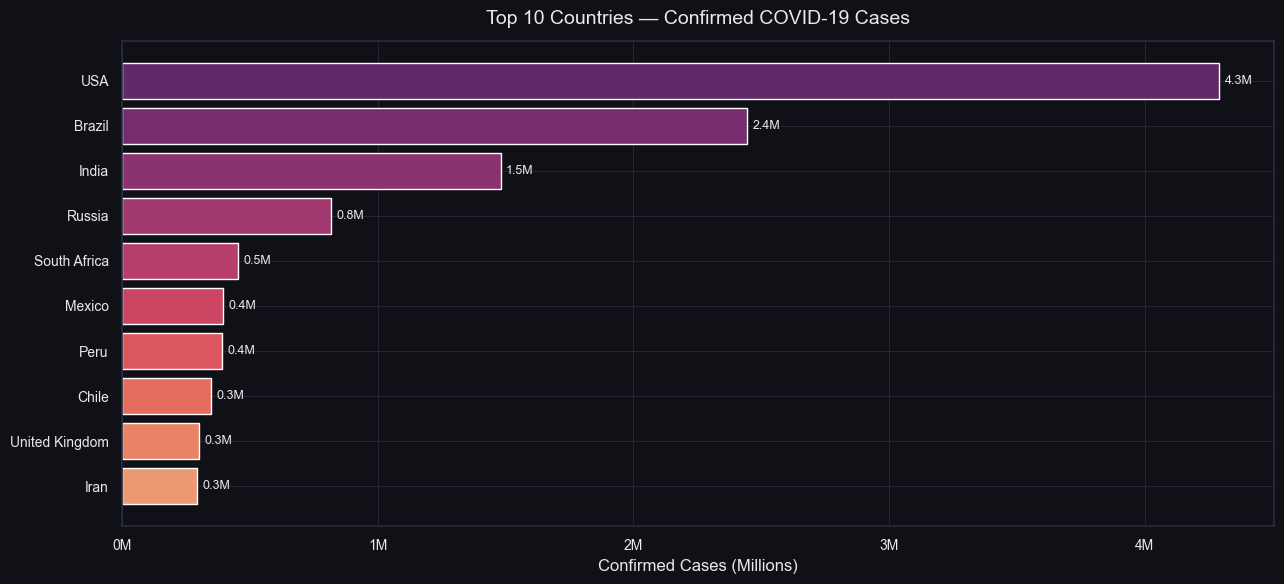

In [74]:

# =============================================================================
# TASK 5 — Top 10 Countries by Confirmed Cases  (horizontal bar)
# =============================================================================
df5 = top10_confirmed.toPandas()
df5 = df5.sort_values("Confirmed")

fig, ax = dark_fig(13, 6)
bars = ax.barh(df5["Area"], df5["Confirmed"] / 1e6,
               color=sns.color_palette("flare", len(df5)))
ax.bar_label(bars, fmt="%.1fM", color=FG, padding=4, fontsize=9)
ax.set_xlabel("Confirmed Cases (Millions)", color=FG)
ax.set_title("Top 10 Countries — Confirmed COVID-19 Cases", fontsize=14, pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
plt.tight_layout()
plt.savefig("output/task5_top10_confirmed.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

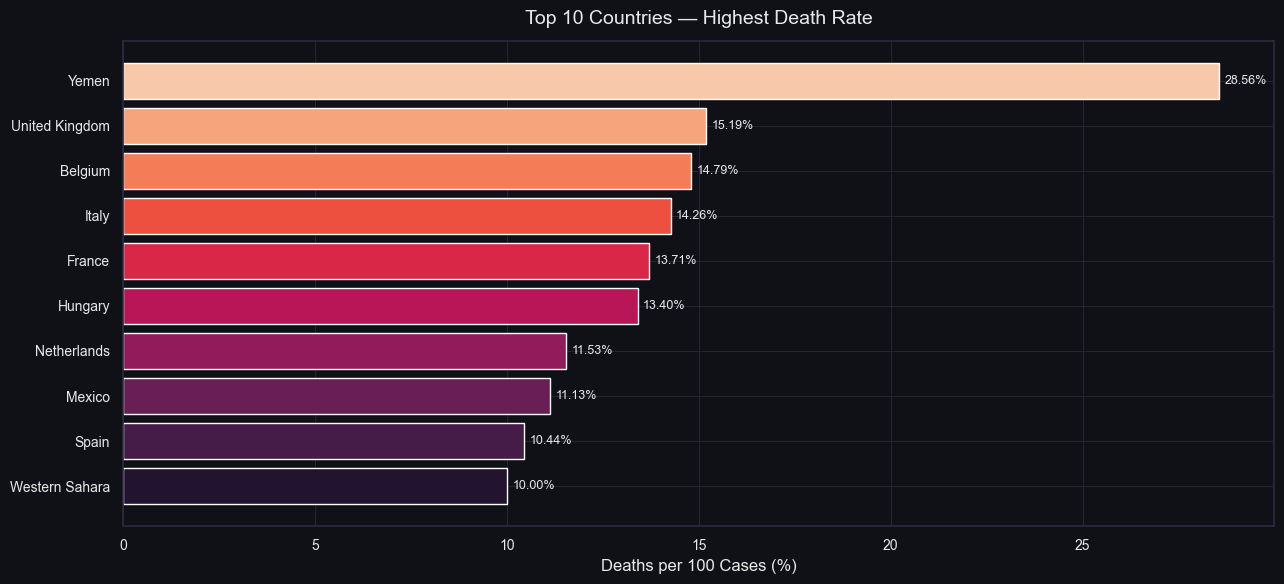

In [75]:

# =============================================================================
# TASK 6 — Top 10 Countries by Death Rate  (horizontal bar)
# =============================================================================
df6 = top10_death_rate.toPandas()
df6 = df6.sort_values("Dper100")

fig, ax = dark_fig(13, 6)
bars = ax.barh(df6["Area"], df6["Dper100"],
               color=sns.color_palette("rocket", len(df6)))
ax.bar_label(bars, fmt="%.2f%%", color=FG, padding=4, fontsize=9)
ax.set_xlabel("Deaths per 100 Cases (%)", color=FG)
ax.set_title("Top 10 Countries — Highest Death Rate", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("output/task6_death_rate.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

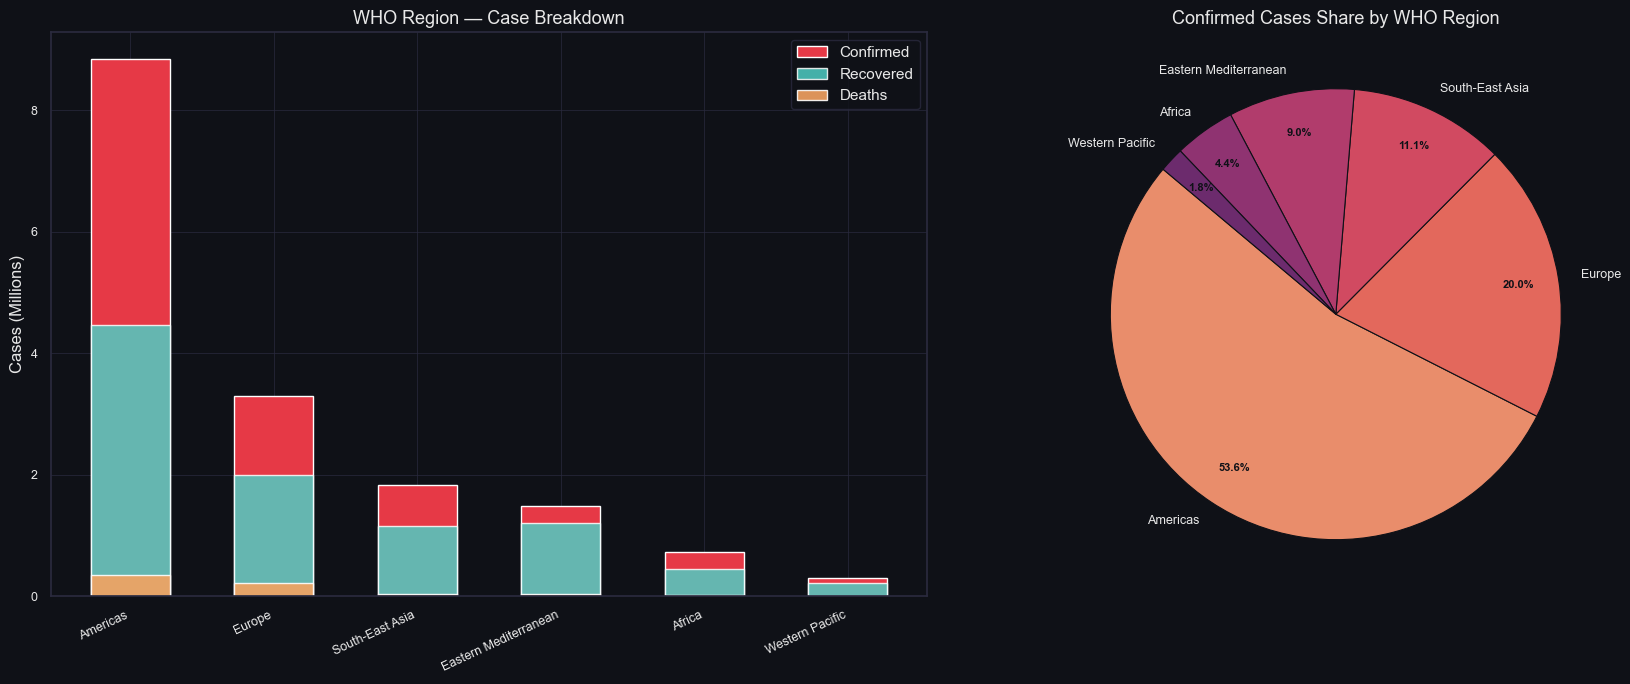

In [76]:

# =============================================================================
# TASK 7 — WHO Region-wise Totals  (stacked bar + pie side by side)
# =============================================================================
df7 = who_region_totals.toPandas()
df7 = df7.sort_values("Total_Confirmed", ascending=False)

fig, (ax1, ax2) = dark_figs(1, 2, w=18, h=7)

# Stacked bar
x = np.arange(len(df7))
w = 0.55
ax1.bar(x, df7["Total_Confirmed"] / 1e6, w, label="Confirmed", color="#e63946")
ax1.bar(x, df7["Total_Recovered"]  / 1e6, w, label="Recovered", color=ACCENT2,  alpha=0.85)
ax1.bar(x, df7["Total_Deaths"]     / 1e6, w, label="Deaths",    color="#f4a261", alpha=0.9)
ax1.set_xticks(x)
ax1.set_xticklabels(df7["WHO Region"], rotation=25, ha="right", color=FG, fontsize=9)
ax1.set_ylabel("Cases (Millions)", color=FG)
ax1.set_title("WHO Region — Case Breakdown", color=FG, fontsize=13)
ax1.legend(facecolor=BG, labelcolor=FG, edgecolor=GRID_C)

# Pie — confirmed share
wedge_colors = sns.color_palette("flare", len(df7))
wedges, texts, autotexts = ax2.pie(
    df7["Total_Confirmed"], labels=df7["WHO Region"],
    autopct="%1.1f%%", colors=wedge_colors,
    pctdistance=0.82, startangle=140,
    wedgeprops=dict(linewidth=0.8, edgecolor=BG)
)
for t in texts:      t.set_color(FG); t.set_fontsize(9)
for at in autotexts: at.set_color(BG); at.set_fontsize(8); at.set_fontweight("bold")
ax2.set_title("Confirmed Cases Share by WHO Region", color=FG, fontsize=13)

plt.tight_layout()
plt.savefig("output/task7_who_region.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()



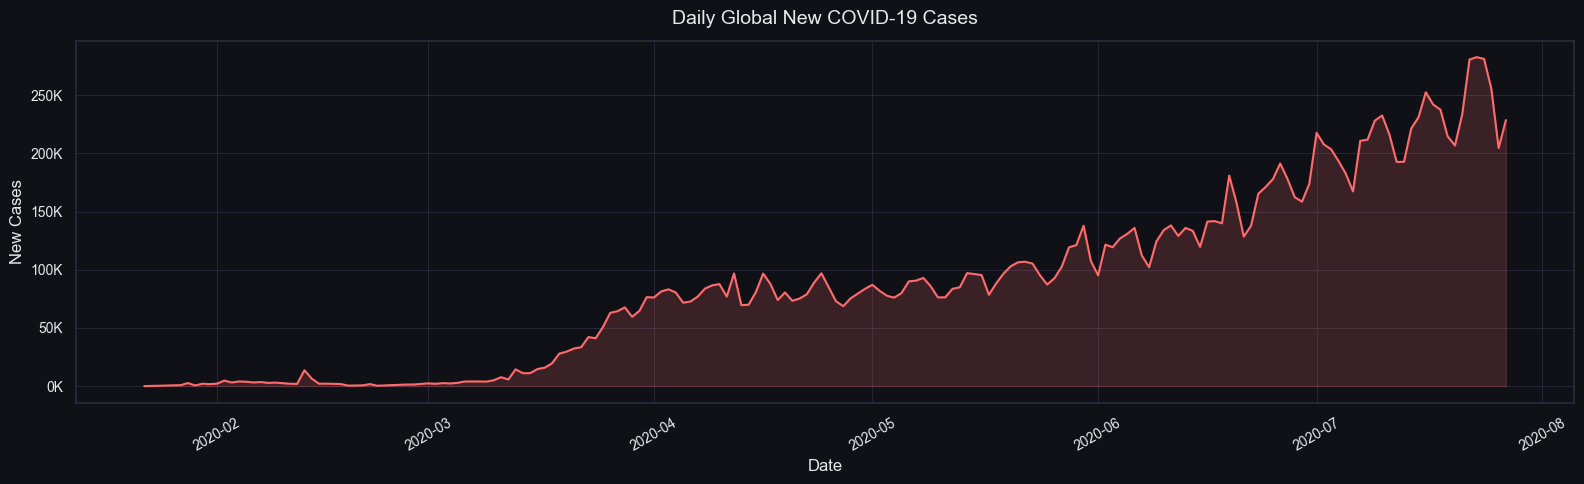

In [77]:

# =============================================================================
# TASK 8 — Daily Global New Cases  (line chart)
# =============================================================================
df8 = daily_new_cases.toPandas()
df8["Date"] = pd.to_datetime(df8["Date"])
df8 = df8.sort_values("Date")

fig, ax = dark_fig(16, 5)
ax.fill_between(df8["Date"], df8["New cases"], alpha=0.18, color=ACCENT)
ax.plot(df8["Date"], df8["New cases"], color=ACCENT, linewidth=1.5)
ax.set_xlabel("Date", color=FG)
ax.set_ylabel("New Cases", color=FG)
ax.set_title("Daily Global New COVID-19 Cases", fontsize=14, pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
plt.xticks(rotation=30, color=FG)
plt.tight_layout()
plt.savefig("output/task8_daily_cases.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


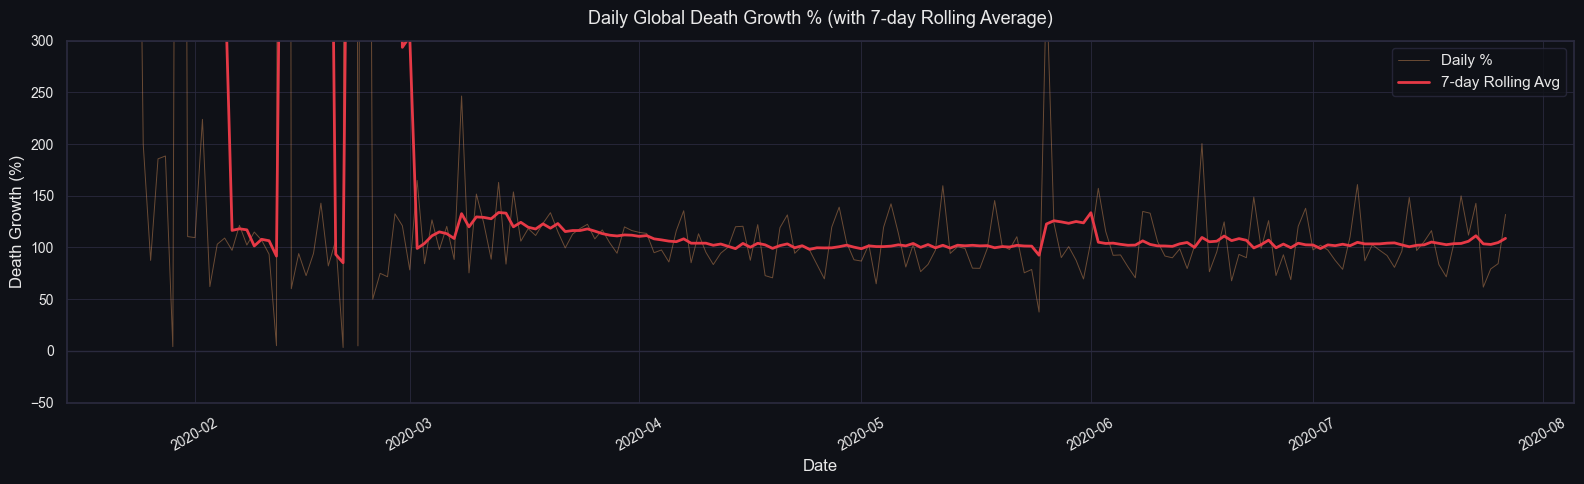

In [78]:


# =============================================================================
# TASK 9 — Daily Death Growth %  (line chart with rolling avg)
# =============================================================================
df9 = death_growth.toPandas()
df9["Date"] = pd.to_datetime(df9["Date"])
df9 = df9.sort_values("Date").dropna(subset=["death_growth_pct"])
df9["rolling_7"] = df9["death_growth_pct"].rolling(7).mean()

fig, ax = dark_fig(16, 5)
ax.plot(df9["Date"], df9["death_growth_pct"], color="#f4a261", linewidth=0.7, alpha=0.4, label="Daily %")
ax.plot(df9["Date"], df9["rolling_7"],        color="#e63946",  linewidth=2,   label="7-day Rolling Avg")
ax.axhline(0, color=GRID_C, linewidth=1)
ax.set_xlabel("Date", color=FG)
ax.set_ylabel("Death Growth (%)", color=FG)
ax.set_title("Daily Global Death Growth % (with 7-day Rolling Average)", fontsize=13, pad=12)
ax.legend(facecolor=BG, labelcolor=FG, edgecolor=GRID_C)
ax.set_ylim(-50, 300)
plt.xticks(rotation=30, color=FG)
plt.tight_layout()
plt.savefig("output/task9_death_growth.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()



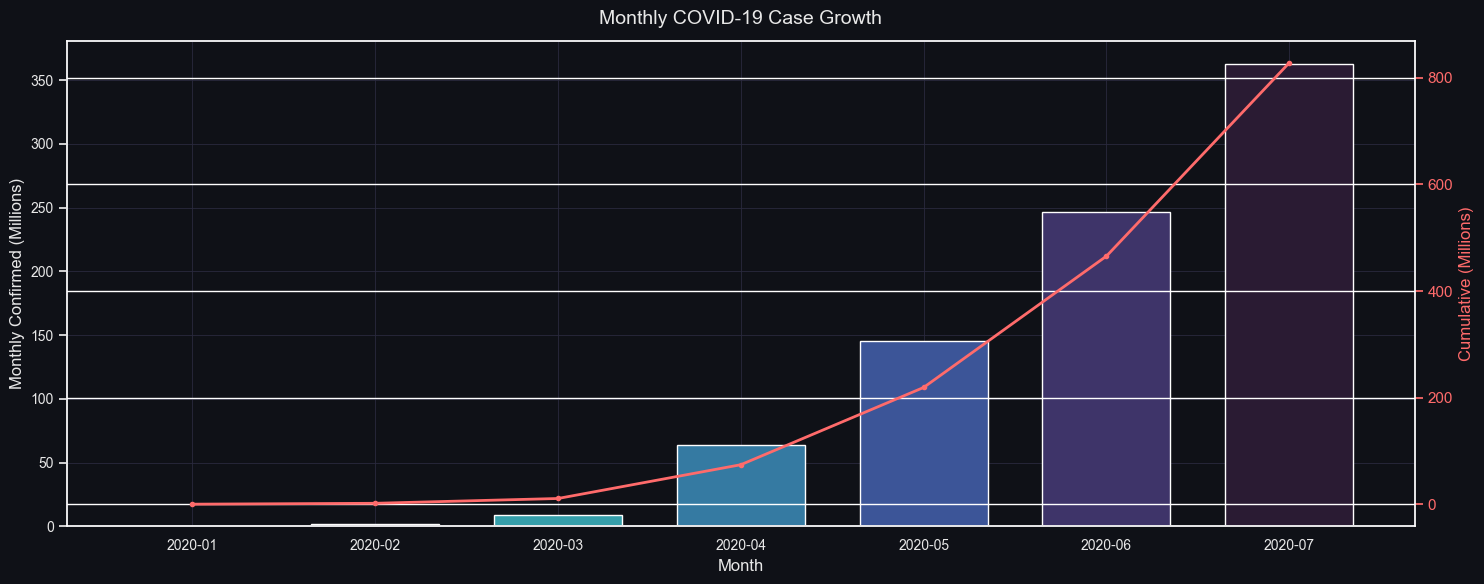

In [79]:

# =============================================================================
# TASK 10 — Monthly COVID Case Growth  (bar + line combo)
# =============================================================================
df10 = monthly_growth.toPandas()
df10["MonthLabel"] = df10["Year"].astype(str) + "-" + df10["Month"].astype(str).str.zfill(2)
df10 = df10.sort_values(["Year", "Month"])

fig, ax = dark_fig(15, 6)
bars = ax.bar(df10["MonthLabel"], df10["Monthly_Confirmed"] / 1e6,
              color=sns.color_palette("mako_r", len(df10)), width=0.7)
ax2_ = ax.twinx()
ax2_.plot(df10["MonthLabel"], df10["Monthly_Confirmed"].cumsum() / 1e6,
          color=ACCENT, linewidth=2, marker="o", markersize=3, label="Cumulative")
ax2_.set_ylabel("Cumulative (Millions)", color=ACCENT)
ax2_.tick_params(colors=ACCENT)
ax2_.set_facecolor(BG)
ax.set_xlabel("Month", color=FG)
ax.set_ylabel("Monthly Confirmed (Millions)", color=FG)
ax.set_title("Monthly COVID-19 Case Growth", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right", color=FG, fontsize=8)
plt.tight_layout()
plt.savefig("output/task10_monthly_growth.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()



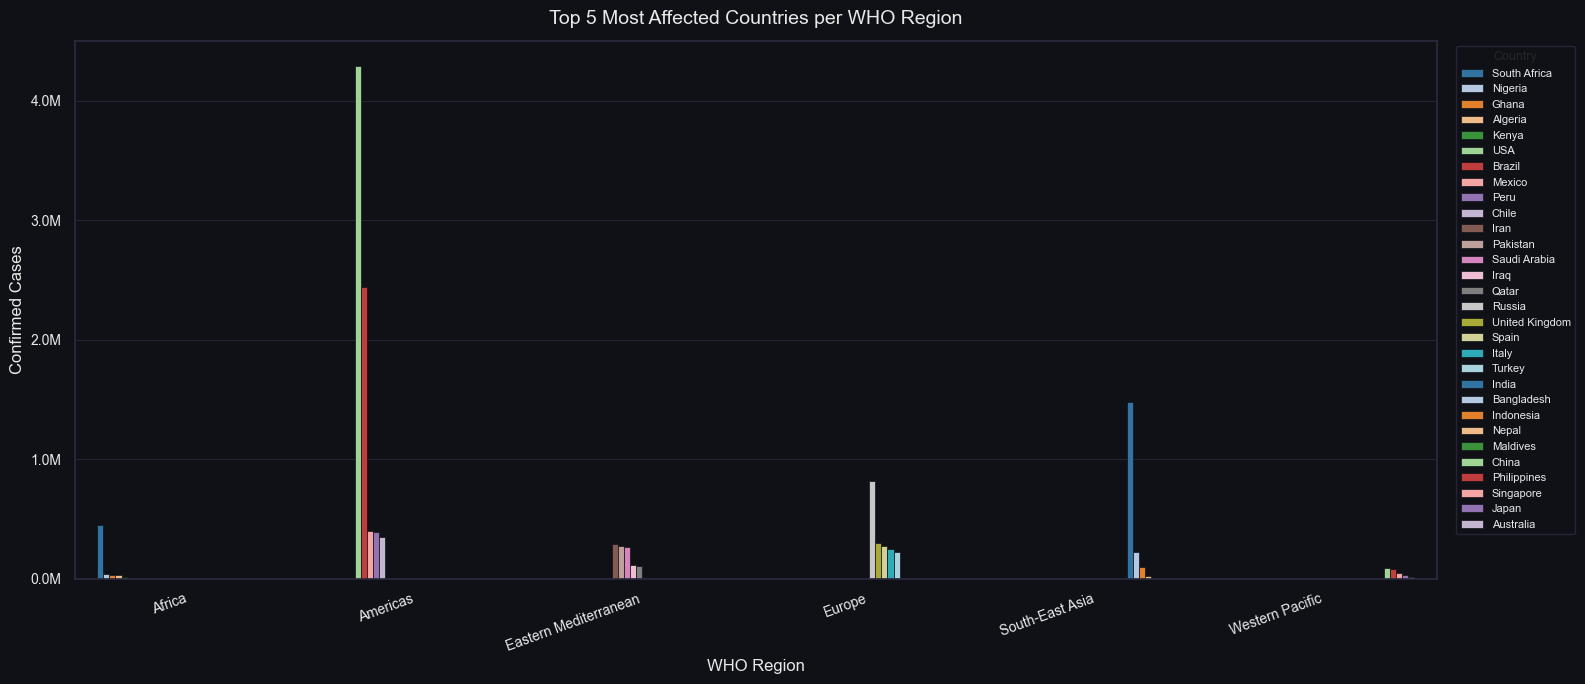

In [80]:

# =============================================================================
# TASK 11 — Top 5 Countries per WHO Region  (grouped bar via seaborn)
# =============================================================================
df11 = top5_per_region.toPandas()

fig, ax = dark_fig(16, 7)
sns.barplot(
    data=df11, x="WHO Region", y="Confirmed", hue="Area",
    palette="tab20", ax=ax, dodge=True,
    edgecolor=BG, linewidth=0.5
)
ax.set_ylabel("Confirmed Cases", color=FG)
ax.set_xlabel("WHO Region", color=FG)
ax.set_title("Top 5 Most Affected Countries per WHO Region", fontsize=14, pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend(
    title="Country", facecolor=BG, labelcolor=FG,
    edgecolor=GRID_C, title_fontsize=9, fontsize=8,
    bbox_to_anchor=(1.01, 1), loc="upper left"
)
plt.xticks(rotation=20, ha="right", color=FG)
plt.tight_layout()
plt.savefig("output/task11_top5_per_region.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()



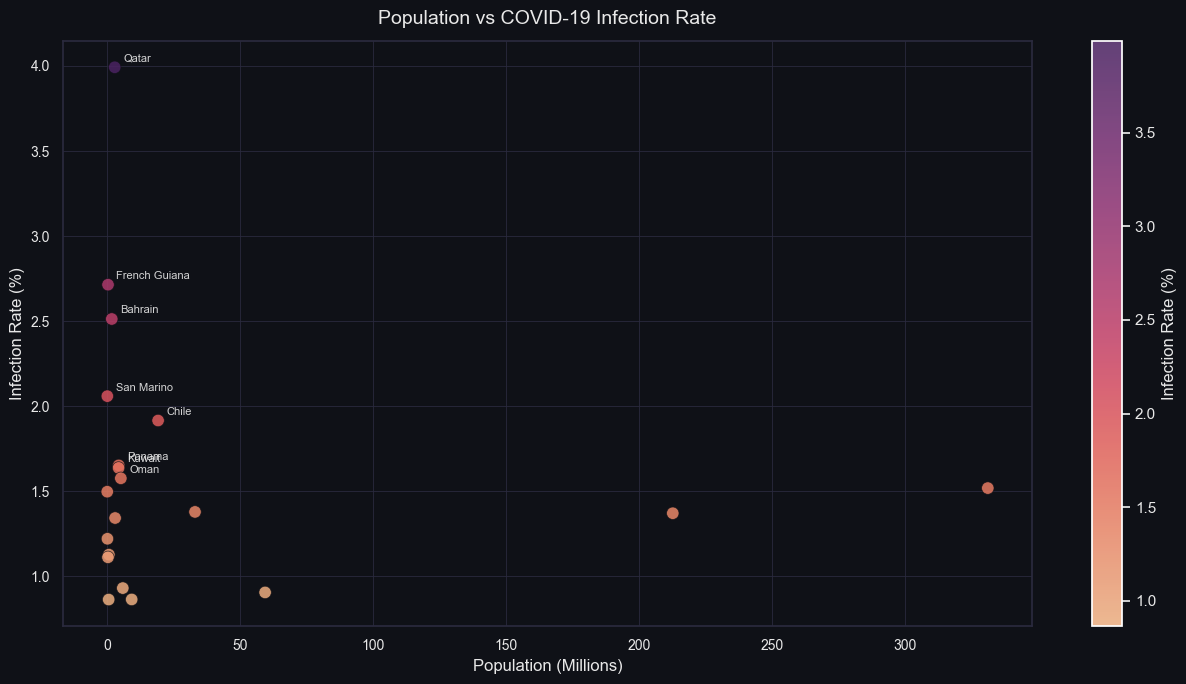

In [81]:

# =============================================================================
# TASK 14 — Infection Rate vs Population  (scatter)
# =============================================================================
df14 = infection_rate.toPandas()

fig, ax = dark_fig(13, 7)
sc = ax.scatter(
    df14["Population"] / 1e6,
    df14["infection_rate"],
    c=df14["infection_rate"],
    cmap="flare", s=80, alpha=0.85, edgecolors=BG, linewidths=0.5
)
for _, row in df14.head(8).iterrows():
    ax.annotate(
        row["Area"],
        (row["Population"] / 1e6, row["infection_rate"]),
        textcoords="offset points", xytext=(6, 4),
        color=FG, fontsize=8, alpha=0.9
    )
cb = plt.colorbar(sc, ax=ax)
cb.ax.yaxis.set_tick_params(color=FG)
cb.ax.tick_params(labelcolor=FG)
cb.set_label("Infection Rate (%)", color=FG)
ax.set_xlabel("Population (Millions)", color=FG)
ax.set_ylabel("Infection Rate (%)", color=FG)
ax.set_title("Population vs COVID-19 Infection Rate", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("output/task14_infection_rate.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()



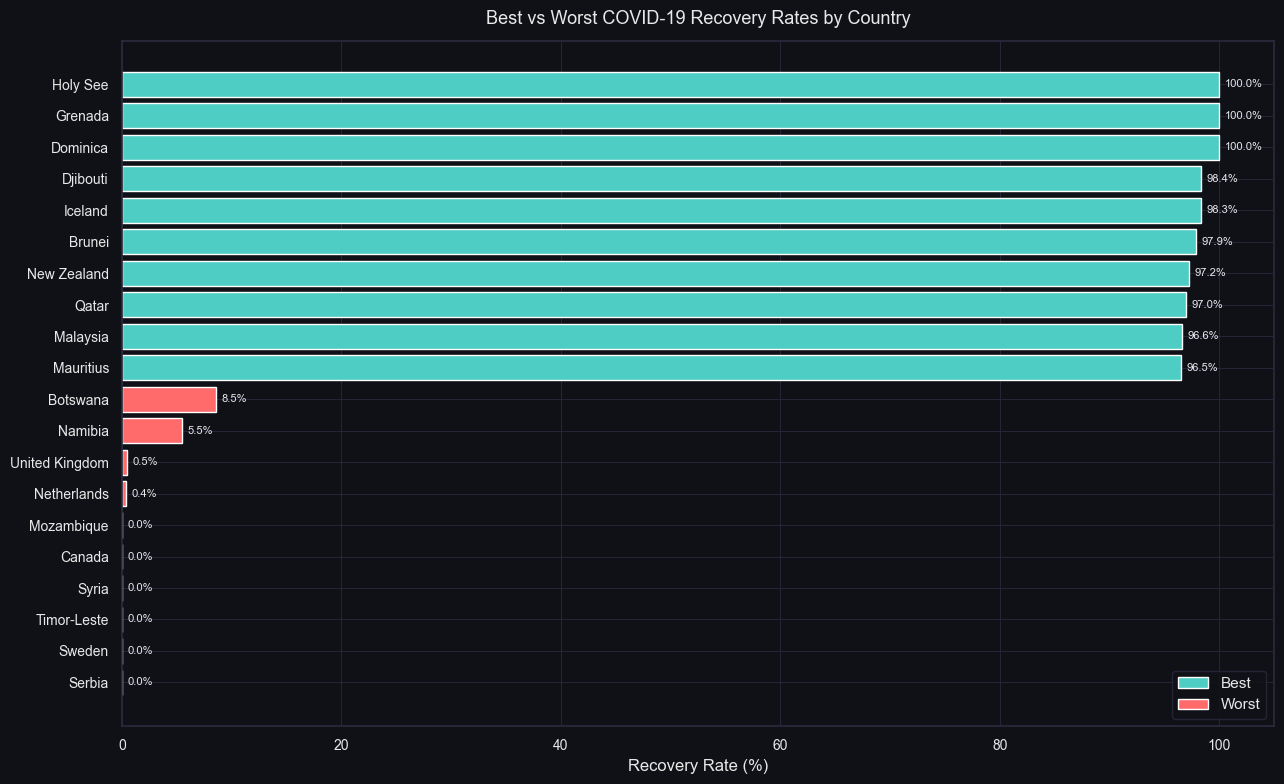

In [82]:

# =============================================================================
# TASK 17 — Recovery Rate  (top & bottom 10 diverging bar)
# =============================================================================
df17 = recovery_rate.toPandas().dropna(subset=["recovery_rate"])
best  = df17.nlargest(10,  "recovery_rate")[["Area", "recovery_rate"]]
worst = df17.nsmallest(10, "recovery_rate")[["Area", "recovery_rate"]]
best["type"]  = "Best"
worst["type"] = "Worst"
df17_plot = pd.concat([best, worst]).sort_values("recovery_rate")

fig, ax = dark_fig(13, 8)
colors = [ACCENT2 if t == "Best" else ACCENT for t in df17_plot["type"]]
bars = ax.barh(df17_plot["Area"], df17_plot["recovery_rate"], color=colors)
ax.bar_label(bars, fmt="%.1f%%", color=FG, padding=4, fontsize=8)
ax.set_xlabel("Recovery Rate (%)", color=FG)
ax.set_title("Best vs Worst COVID-19 Recovery Rates by Country", fontsize=13, pad=12)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=ACCENT2, label="Best"),
                   Patch(facecolor=ACCENT,  label="Worst")]
ax.legend(handles=legend_elements, facecolor=BG, labelcolor=FG, edgecolor=GRID_C)
plt.tight_layout()
plt.savefig("output/task17_recovery_rate.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


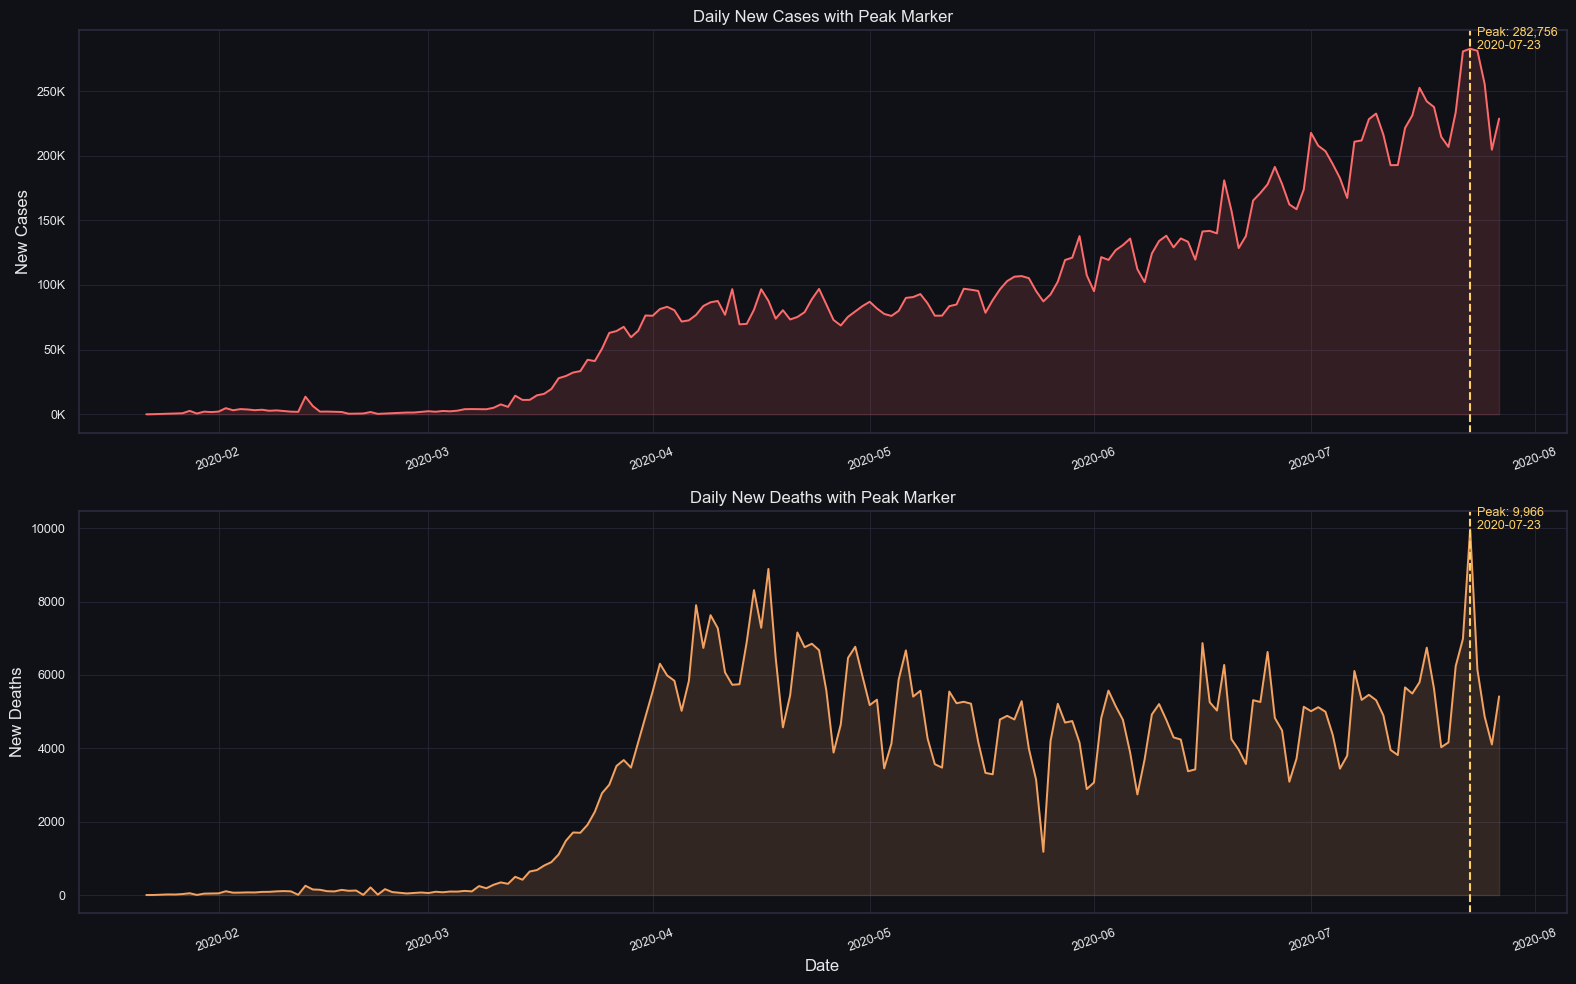

In [83]:


# =============================================================================
# TASK 19 — Pandemic Peaks  (new cases line + peak markers)
# =============================================================================
df_days_full = days.toPandas()
df_days_full["Date"] = pd.to_datetime(df_days_full["Date"])
df_days_full = df_days_full.sort_values("Date")

pk_cases  = peak_cases .toPandas().iloc[0]
pk_deaths = peak_deaths.toPandas().iloc[0]

fig, (ax1, ax2) = dark_figs(2, 1, w=16, h=10)

# New cases
ax1.fill_between(df_days_full["Date"], df_days_full["New cases"], alpha=0.15, color=ACCENT)
ax1.plot(df_days_full["Date"], df_days_full["New cases"], color=ACCENT, linewidth=1.4)
peak_date_c = pd.to_datetime(pk_cases["Date"])
ax1.axvline(peak_date_c, color="#ffd166", linewidth=1.5, linestyle="--")
ax1.annotate(
    f"  Peak: {int(pk_cases['New cases']):,}\n  {pk_cases['Date']}",
    xy=(peak_date_c, pk_cases["New cases"]),
    color="#ffd166", fontsize=9
)
ax1.set_title("Daily New Cases with Peak Marker", color=FG, fontsize=12)
ax1.set_ylabel("New Cases", color=FG)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))

# New deaths
ax2.fill_between(df_days_full["Date"], df_days_full["New deaths"], alpha=0.15, color="#f4a261")
ax2.plot(df_days_full["Date"], df_days_full["New deaths"], color="#f4a261", linewidth=1.4)
peak_date_d = pd.to_datetime(pk_deaths["Date"])
ax2.axvline(peak_date_d, color="#ffd166", linewidth=1.5, linestyle="--")
ax2.annotate(
    f"  Peak: {int(pk_deaths['New deaths']):,}\n  {pk_deaths['Date']}",
    xy=(peak_date_d, pk_deaths["New deaths"]),
    color="#ffd166", fontsize=9
)
ax2.set_title("Daily New Deaths with Peak Marker", color=FG, fontsize=12)
ax2.set_ylabel("New Deaths", color=FG)
ax2.set_xlabel("Date", color=FG)

for ax in (ax1, ax2):
    ax.set_facecolor(BG)
    for spine in ax.spines.values(): spine.set_edgecolor(GRID_C)
    ax.tick_params(colors=FG)
    plt.setp(ax.get_xticklabels(), rotation=20, color=FG)

plt.tight_layout()
plt.savefig("output/task19_peaks.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()



C:\Users\pmoh3005\AppData\Local\Temp\ipykernel_33612\3414117326.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sev_counts.index, y=sev_counts.values,


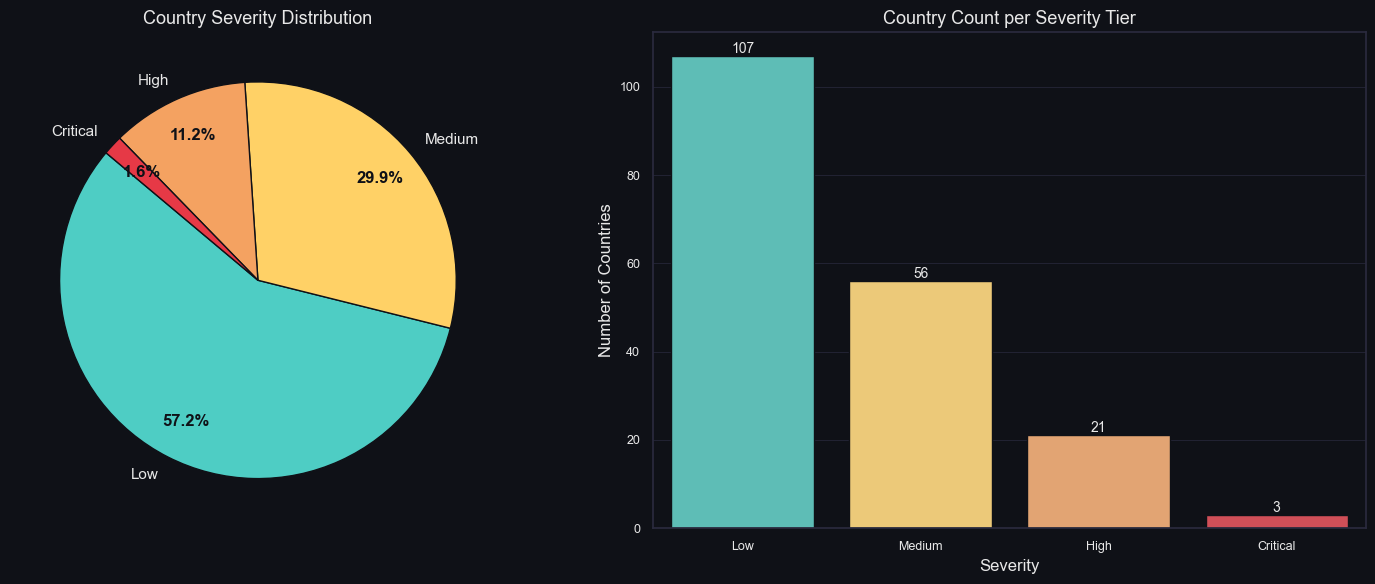

In [84]:

# =============================================================================
# TASK 20 — Severity Category  (pie + count bar)
# =============================================================================
df20 = severity_df.toPandas()
sev_counts = df20["Severity"].value_counts().reindex(["Low", "Medium", "High", "Critical"])

sev_colors = {"Low": "#4ecdc4", "Medium": "#ffd166", "High": "#f4a261", "Critical": "#e63946"}
colors_ordered = [sev_colors[s] for s in sev_counts.index]

fig, (ax1, ax2) = dark_figs(1, 2, w=15, h=6)

# Pie
wedges, texts, autotexts = ax1.pie(
    sev_counts, labels=sev_counts.index,
    autopct="%1.1f%%", colors=colors_ordered,
    startangle=140, pctdistance=0.8,
    wedgeprops=dict(linewidth=1, edgecolor=BG)
)
for t in texts:      t.set_color(FG);  t.set_fontsize(11)
for at in autotexts: at.set_color(BG); at.set_fontweight("bold")
ax1.set_title("Country Severity Distribution", color=FG, fontsize=13)

# Count bar
sns.barplot(x=sev_counts.index, y=sev_counts.values,
            palette=colors_ordered, ax=ax2, edgecolor=BG)
ax2.set_ylabel("Number of Countries", color=FG)
ax2.set_xlabel("Severity", color=FG)
ax2.set_title("Country Count per Severity Tier", color=FG, fontsize=13)
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height())}",
                 (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha="center", va="bottom", color=FG, fontsize=10)

plt.tight_layout()
plt.savefig("output/task20_severity.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()